## 1장 2강: 데이터 분석 기초

### 2. 탐색적 데이터 분석(EDA, Exploratory Data Analysis)과 결측치/이상치

### 4. 타이타닉(Titanic) 탑승객 데이터 분석
#### 4.1 데이터 로드 및 결측치, 이상치 처리

타이타닉(Titanic) 탑승객 데이터 로드 하기

- df.head() : 앞쪽 5개 데이터 조회
- df.tail() : 뒤쪽 5개 데이터 조회

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')

In [ ]:
# df.iloc[:5]
df[:5]

데이터 요약 및 통계 확인 하기

In [ ]:
df.columns # 데이터 프레임 컬럼 목록 출력

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [ ]:
df.info() # 결측치 확인하기

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
df.describe() # 이상치 확인하기

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


결측치 파악하기

In [8]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

숫자형 데이터(나이): 전체 탑승객의 '평균(mean)'으로 빈칸 채우기

In [13]:
mean_age = df['age'].mean()
print(f'평균 나이 : {mean_age}')

df['age'] = df['age'].fillna(mean_age)

df.isna().sum()

평균 나이 : 29.69911764705882


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

문자/범주형 데이터(탑승 항구): 가장 많이 탑승한 곳인 '최빈값(mode)'으로 빈칸 채우기

In [15]:
mode_embarked = df['embark_town'].mode()[0]

mode_embarked

'Southampton'

In [18]:
df['embark_town'] = df['embark_town'].fillna(mode_embarked)
df['embarked'] = df['embark_town'].map(lambda x: x[0].upper())

df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

특정 컬럼(deck) 을 '기준'으로 좌우(열 방향) 데이터를 채우기

In [21]:
df['deck'] = df['deck'].ffill()
df['deck'] = df['deck'].bfill()
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

너무 비싼 요금(이상치) 걸러내기

요금 평균 : 32.204207968574636, 중간값 : 14.4542


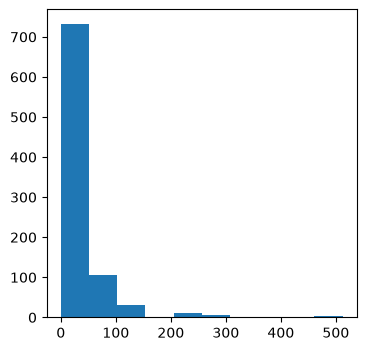

In [26]:
print(f'요금 평균 : {df['fare'].mean()}, 중간값 : {df['fare'].median()}')

plt.figure(figsize=(4, 4))
plt.hist(df['fare'], bins=10)
plt.show()

결측치/이상치 보완 결과 확인

In [ ]:
df = df[df['fare'] <= 300]

df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [29]:
df[df['fare'] > 300].count()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

#### 4.2 중복 데이터 처리하기

중복 데이터 확인하기

In [ ]:
# duplicated() : 중복된 값인지 True, False로 반환
df.duplicated().sum()

np.int64(39)

중복 데이터 제거하기

In [ ]:
# drop_duplicates() : 첫번째 항목 제외한 중복 값 삭제
# df.drop_duplicates()[:100]
df = df.drop_duplicates().reset_index(drop=True)
# 중복 데이터 삭제시에 인덱스 번호는 전 상태로 유지되서 순차적으로 정리되지 않음.
# 이를 해결 하기 위해 reset_index()를 통해서 인덱스 번호를 0 부터 다시 순차적으로 선언하여 반환함.
print(f'중복 데이터 수 : {df.duplicated().sum()}')

중복 데이터 수 : 0


#### 4.3 그래프로 시각화하기

내 컴퓨터에 맞는 한글 폰트 설정하기

In [36]:
import platform
from matplotlib import rc

os_name = platform.system()
if os_name == 'Windows':
    rc('font', family='Malgun Gothic')
else :
    rc('font', family='AppleGothic')



도화지(Figure)와 3개의 액자(Axes) 준비

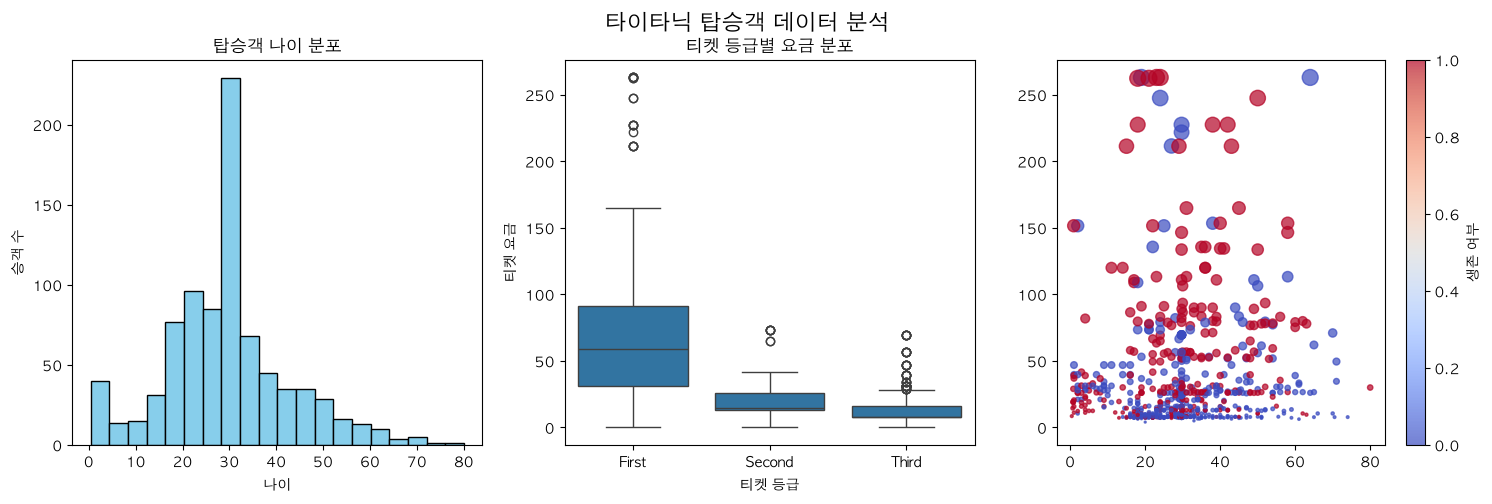

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('타이타닉 탑승객 데이터 분석', fontsize=16)

# [히스토그램] 탑승객 나이 분포
axes[0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('탑승객 나이 분포')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('승객 수')

# [박스 플롯] 티켓 등급에 따른 요금 이상치 확인
sns.boxplot(x='class', y='fare', data=df, ax=axes[1])
axes[1].set_title('티켓 등급별 요금 분포')
axes[1].set_xlabel('티켓 등급')
axes[1].set_ylabel('티켓 요금')

# [산점도] 나이와 클리닝된 요금의 관계
scatter = axes[2].scatter(
    df['age'],
    df['fare'],
    c=df['survived'], # 원 마다 값에 따른 색 변화
    cmap='coolwarm', # 1 - red, 0 - blue
    s=df['fare'] / 2, # 산점도 원 크기
    alpha = 0.7 # 불투명도
)

fig.colorbar(scatter, ax=axes[2], label='생존 여부')

그래프로 분석하기